<b>Salary Survey Clean and Wrangle</b>

# 1. Load & Inspect the Raw Data

In [2]:
import os
import re
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

df = pd.read_csv('../Dataset/Salary Survey 2021.csv')
df_raw = df.copy()  # untouched snapshot, used only for before/after comparisons

In [3]:
print("Shape (rows, cols):", df.shape)
df.info()

Shape (rows, cols): (28225, 18)
<class 'pandas.DataFrame'>
RangeIndex: 28225 entries, 0 to 28224
Data columns (total 18 columns):
 #   Column                                                                                                                                                                                                                                Non-Null Count  Dtype  
---  ------                                                                                                                                                                                                                                --------------  -----  
 0   Timestamp                                                                                                                                                                                                                             28225 non-null  str    
 1   How old are you?                                                                        

**Data Inspecting notes:**
- 28,225 rows, 18 columns, all loaded as `str` except one `float64` column
- Several columns are long question strings straight from the Google Form and these needs to rename to make it readable and easy to do data analysis and visualization

In [4]:
# Missingness profile: raw counts + percentage, sorted worst-first
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_pct
"If ""Other,"" please indicate the currency here:",28000,99.20
"If your income needs additional context, please provide it here:",25172,89.18
"If your job title needs additional context, please clarify here:",20932,74.16
"How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.",7375,26.13
"If you're in the U.S., what state do you work in?",5078,17.99
What is your highest level of education completed?,241,0.85
What is your race? (Choose all that apply.),197,0.70
What is your gender?,186,0.66
What industry do you work in?,86,0.30
What city do you work in?,85,0.30


**Diagnosis:** the columns we're actually keeping for analysis (age, industry, job
title, salary, currency, country, experience, education, gender) are almost entirely complete — under 1%
missing each, except `education` (~0.9%) and `gender` (~0.7%). The heavily-missing columns in the chart
above (state, city, "additional context" free-text fields, race) are ones we're dropping anyway because
they're out of scope for this analysis, so their missingness doesn't drive any cleaning decisions here.

## Functions

### print_shape

In [5]:
def print_shape(option="both"):
    df_raw_rows, df_raw_cols = df_raw.shape
    df_rows, df_cols = df.shape

    option = option.lower()

    if option == "row" or option == "both":
        print(f"Total Rows: {df_rows}/{df_raw_rows}")

    if option == "col" or option == "both":
        print(f"Total Columns: {df_cols}/{df_raw_cols}")

print_shape("col")

Total Columns: 18/18


### print_unique_summary

In [6]:
def print_unique_summary(df_name, column_name, max_display=15):
    unique_vals = df_name[column_name].unique()
    num_unique = df_name[column_name].nunique()

    print(f"Total Unique Count (nunique): {num_unique}")
    if num_unique <= max_display:
        print(f"Unique Values (unique): {unique_vals}\n")
    else:
        print(f"Unique Values (first {max_display} shown): {unique_vals[:max_display]}\n")

### print_null_sum

In [7]:
def print_null_sum(df_name, column_name):
    print("Total NULL Values:", df_name[column_name].isnull().sum())

### map_category
<b>Description:</b> keyword/regex matching used to collapse free-text columns (industry, job title,
country) into a manageable number of categories.

In [8]:
def map_category(value, mapping):
    if pd.isna(value):
        return value
    for category, pattern in mapping.items():
        if pd.Series([value]).str.contains(pattern, case=False, na=False).iloc[0]:
            return category
    return "Other"


# 2. Column Trimming & Renaming

## Remove columns out of scope for this analysis
- `Timestamp` - submission metadata, not an analysis variable
- `If your job title needs additional context, please clarify here:` - free-text, low fill rate, not
  needed once `job_title` is categorized
- `How much additional monetary compensation...` - separate from base `annual_salary`, out of scope
- `If "Other," please indicate the currency here:` - only fills in when `currency == 'Other'`, which we
  drop entirely later (see Section on `currency`)
- `If your income needs additional context, please provide it here:` - free-text, out of scope
- `If you're in the U.S., what state do you work in?` - US-only follow-up, out of scope for a
  country-level analysis
- `What city do you work in?` - too granular/high-cardinality for this analysis
- `How many years of professional work experience do you have overall?` - redundant for current years of experience
- `What is your race? (Choose all that apply.)` - multi-select free text, out of scope for this pass

In [9]:
df = df.drop(columns=[
    'Timestamp',
    'If your job title needs additional context, please clarify here:',
    'How much additional monetary compensation do you get, if any (for example, bonuses or overtime in an average year)? Please only include monetary compensation here, not the value of benefits.',
    'If "Other," please indicate the currency here: ',
    'If your income needs additional context, please provide it here:',
    "If you're in the U.S., what state do you work in?",
    'What city do you work in?',
    'How many years of professional work experience do you have overall?',
    'What is your race? (Choose all that apply.)'
])

print_shape()

Total Rows: 28225/28225
Total Columns: 9/18


## Rename kept columns to analysis-friendly names
- `age_range` = 'How old are you?'
- `industry` = 'What industry do you work in?'
- `job_title` = 'Job title'
- `annual_salary` = "What is your annual salary? (...)"
- `currency` = 'Please indicate the currency'
- `country` = 'What country do you work in?'
- `current_years_experience` = 'How many years of professional work experience do you have in your field?'
- `education` = 'What is your highest level of education completed?'
- `gender` = 'What is your gender?'

In [10]:
df = df.rename(columns={
    'How old are you?': 'age_range',
    'What industry do you work in?': 'industry',
    'Job title': 'job_title',
    "What is your annual salary? (You'll indicate the currency in a later question. If you are part-time or hourly, please enter an annualized equivalent -- what you would earn if you worked the job 40 hours a week, 52 weeks a year.)": 'annual_salary',
    'Please indicate the currency': 'currency',
    'What country do you work in?': 'country',
    'How many years of professional work experience do you have in your field?': 'current_years_experience',
    'What is your highest level of education completed?': 'education',
    'What is your gender?': 'gender'
})

print_shape()
df.columns.tolist()

Total Rows: 28225/28225
Total Columns: 9/18


['age_range',
 'industry',
 'job_title',
 'annual_salary',
 'currency',
 'country',
 'current_years_experience',
 'education',
 'gender']

## Cleaning Log — Column Trimming & Renaming
- The raw export had 18 columns; 9 are kept for this analysis (see list above).
- Removed columns are either metadata (`Timestamp`), redundant with a kept column (overall years of
  experience vs. field-specific years), too granular/high-cardinality for this pass (city, race
  multi-select), or optional free-text follow-ups with low fill rates that don't add analysis value.
- Long question-text headers were renamed to lowercase names for readability in the rest of the
  notebook.

# 3. Per-Column Diagnosis & Cleaning

For each column, we inspect it, then clean it directly to main dataframe `df`. And also, `df_temp` has been removed for cleaner coding.

## age_range

In [11]:
print_unique_summary(df, "age_range")
print_null_sum(df, "age_range")

Total Unique Count (nunique): 7
Unique Values (unique): <StringArray>
['25-34', '45-54', '35-44', '18-24', '65 or over', '55-64', 'under 18']
Length: 7, dtype: str

Total NULL Values: 0


**Diagnosis:** 7 clean, non-overlapping age range (`under 18` through `65 or over`), no nulls, no
duplicate/inconsistent spellings. 

**Decision:** no value cleaning needed.

In [12]:
age_order = ['under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65 or over']
df['age_range'] = pd.Categorical(df['age_range'], categories=age_order, ordered=True)

df['age_range'].cat.categories

Index(['under 18', '18-24', '25-34', '35-44', '45-54', '55-64', '65 or over'], dtype='str')

## industry

In [13]:
print_unique_summary(df, "industry")
print_null_sum(df, "industry")

Total Unique Count (nunique): 1225
Unique Values (first 15 shown): <StringArray>
[        'Education (Higher Education)',
                    'Computing or Tech',
        'Accounting, Banking & Finance',
                           'Nonprofits',
                           'Publishing',
        'Education (Primary/Secondary)',
                                  'Law',
                          'Health care',
       'Utilities & Telecommunications',
               'Business or Consulting',
                         'Art & Design',
 'Government and Public Administration',
                       'Public Library',
         'Engineering or Manufacturing',
                      'Media & Digital']
Length: 15, dtype: str

Total NULL Values: 86


**Diagnosis:** About 1,225 unique free-text values for what should be a handful of industry buckets.
Many are just the same industry written differently (e.g. `Software Development` vs
`Software/Programming`). There's also noise (`lifeguard`, `study`, single words) and some real
responses like *"I'm a student, no job"*, these matter later since they explain low-end salary
outliers instead of looking like bad data.

**Decision:** Group values into about 20 broad categories using keyword matching (`map_category`),
instead of matching all 1,225 values by hand. Some niche or junk entries end up in `Other`.

In [14]:
industry_mapping = {
    "Contact Center Services": r"\bcall\b|contact|customer service|\bbpo\b|business process|customer",
    "Education": r"teacher|educ|school|university|acade|phd|ed ?tech",
    "Health": r"health|medical|hospital|nursing|pharma|\bcare\b|psycho",
    "Biotech": r"biotech|bitech",
    "Legal": r"law|legal|attorney",
    "Government": r"government|public admin|civil service|military|govt",
    "Nonprofit": r"nonprofit|non-profit|ngo|charity",
    "Marketing": r"market|adverti|public relations",
    "Retail/Sales": r"retail|\bsale\b|e-commerce",
    "Engineering/Manufacturing": r"manufactur|engineer|construction|industrial",
    "Media/Entertainment": r"media|publish|journal|entertainment|film|music",
    "Hospitality": r"hospitality|restaurant|hotel|\bfood\b|\bchild\b|coffee",
    "Arts/Design": r"\bart\b|design|creative",
    "Real Estate": r"real estate|property",
    "Transportation": r"transport|logistics|shipping|airline",
    "Agriculture": r"agricult|\bfarm\b",
    "Energy": r"energy|\boil\b|\bgas\b|utilit",
    "Insurance": r"insurance",
    "Vet": r"vet|animal|\bcat\b|\bdog\b",
    "Business/Consulting": r"business|consult",
    "Information Technology": r"software|\bit\b|comput|\bdata\b|technology|information|cyber",
    "Finance": r"banking|finance|accounting|investment",
}

df["industry"] = df["industry"].apply(lambda x: map_category(x, industry_mapping))
df["industry"] = df["industry"].fillna("Not Specified")

print_unique_summary(df, "industry")
print_null_sum(df, "industry")
df["industry"].value_counts()

Total Unique Count (nunique): 24
Unique Values (first 15 shown): <StringArray>
[                'Education',    'Information Technology',
                   'Finance',                 'Nonprofit',
       'Media/Entertainment',                     'Legal',
                    'Health',                    'Energy',
       'Business/Consulting',               'Arts/Design',
                'Government',                     'Other',
 'Engineering/Manufacturing',                 'Marketing',
              'Retail/Sales']
Length: 15, dtype: str

Total NULL Values: 0


industry
Information Technology       4776
Education                    3433
Nonprofit                    2430
Health                       2419
Other                        2219
Engineering/Manufacturing    2204
Government                   1942
Finance                      1832
Marketing                    1157
Legal                        1150
Media/Entertainment          1124
Business/Consulting           900
Insurance                     534
Retail/Sales                  523
Energy                        427
Arts/Design                   370
Transportation                310
Agriculture                   140
Biotech                        94
Not Specified                  86
Real Estate                    56
Hospitality                    55
Vet                            27
Contact Center Services        17
Name: count, dtype: int64

## job_title

In [15]:
print_unique_summary(df, "job_title")
print_null_sum(df, "job_title")

Total Unique Count (nunique): 14434
Unique Values (first 15 shown): <StringArray>
[                                            'Research and Instruction Librarian',
                                       'Change & Internal Communications Manager',
                                                           'Marketing Specialist',
                                                                'Program Manager',
                                                             'Accounting Manager',
                                                 'Scholarly Publishing Librarian',
                                                           'Publishing Assistant',
                                                                      'Librarian',
                                                                'Systems Analyst',
                                                              'Senior Accountant',
                                                                 'Office Manager',
 'Dep

**Diagnosis:** 14,400 unique free-text job titles, by far the highest-cardinality column in the
dataset, plus a small amount of obvious junk (`'j'`, `'goashidfhu'`) mixed in with legitimate niche
titles. Same problem as `industry`, so the same keyword-mapping approach is used.

In [16]:
job_title_mapping = {
    # Engineering / Tech
    "Software Engineer": r"software engineer|swe\b|backend|frontend|full.?stack",
    "Data Scientist/Analyst": r"data scientist|data analyst|data engineer",
    "IT/Systems": r"\bit\b|systems admin|network admin|help.?desk|sysadmin",
    "Product Manager": r"product manager|product owner",
    "Project Manager": r"project manager|program manager|\bpmp?\b",
    "UX/UI Designer": r"ux|ui designer|user experience|user interface",
    "QA/Test Engineer": r"qa\b|quality assurance|test engineer",
    "DevOps/Cloud": r"devops|cloud engineer|site reliability|\bsre\b",

    # Management / Leadership
    "Executive (C-Suite)": r"\bceo\b|\bcfo\b|\bcoo\b|\bcto\b|chief .* officer|president",
    "Director": r"\bdirector\b",
    "VP/Senior Leadership": r"\bvp\b|vice president|senior vice president",
    "Manager (General)": r"\bmanager\b",
    "Supervisor": r"supervisor",
    "Team Lead": r"team lead|\blead\b",

    # Admin / Office
    "Administrative Assistant": r"administrative assistant|admin assistant|office assistant",
    "Executive Assistant": r"executive assistant|\bea\b",
    "Office Manager": r"office manager",
    "Receptionist": r"receptionist|front desk",
    "Coordinator": r"coordinator",

    # Finance / Accounting
    "Accountant": r"accountant|accounting",
    "Financial Analyst": r"financial analyst|finance analyst",
    "Bookkeeper": r"bookkeep",
    "Auditor": r"auditor|audit",
    "Controller": r"controller",

    # HR
    "HR Generalist/Manager": r"human resources|\bhr\b",
    "Recruiter": r"recruiter|talent acquisition",

    # Sales / Marketing
    "Sales Representative": r"sales rep|sales associate|account executive",
    "Sales Manager": r"sales manager",
    "Marketing Manager": r"marketing manager|marketing specialist",
    "Content/Copywriter": r"content writer|copywriter|content creator",
    "Social Media": r"social media",

    # Education
    "Teacher (K-12)": r"teacher|k-12|elementary|middle school",
    "Professor/Faculty": r"professor|faculty|lecturer",
    "Librarian": r"librarian",

    # Customer-facing / Support
    "Customer Service": r"customer service|client service",
    "Consultant": r"consultant",

    # Creative
    "Graphic Designer": r"graphic designer",
    "Writer/Editor": r"writer|editor|journalist",

    # Skilled trades / Other
    "Engineer (Non-software)": r"engineer",  # broad catch-all for civil/mechanical/electrical etc
    "Analyst (General)": r"analyst",
    "Social Worker": r"social worker",
}

df["job_title"] = df["job_title"].apply(lambda x: map_category(x, job_title_mapping))
df["job_title"] = df["job_title"].fillna("Not Specified")

print_unique_summary(df, "job_title")
print_null_sum(df, "job_title")
df["job_title"].value_counts().head(20)

Total Unique Count (nunique): 41
Unique Values (first 15 shown): <StringArray>
[              'Librarian',       'Manager (General)',
       'Marketing Manager',         'Project Manager',
                   'Other',       'Analyst (General)',
              'Accountant',                'Director',
             'Coordinator',     'Executive Assistant',
        'Graphic Designer', 'Engineer (Non-software)',
           'Writer/Editor',            'Receptionist',
               'Team Lead']
Length: 15, dtype: str

Total NULL Values: 0


job_title
Other                      9103
Manager (General)          4120
Director                   2564
Analyst (General)          1229
Engineer (Non-software)    1121
Coordinator                1038
Software Engineer           998
Project Manager             862
Writer/Editor               659
Consultant                  492
Teacher (K-12)              479
Team Lead                   471
Librarian                   426
Data Scientist/Analyst      405
Professor/Faculty           369
Executive (C-Suite)         351
IT/Systems                  336
Supervisor                  333
HR Generalist/Manager       293
Product Manager             291
Name: count, dtype: int64

## annual_salary

In [17]:
print_null_sum(df, "annual_salary")
print("annual_salary dtype:", df["annual_salary"].dtype)
df[["annual_salary"]].sample(3, random_state=1)

Total NULL Values: 0
annual_salary dtype: str


,annual_salary
8412,"54,000"
9427,"81,000"
330,"55,000"


**Diagnosis:** Loaded as a string because thousands separators (`"55,000"`) make it non-numeric to
pandas. Confirmed with a direct `.astype(float)` attempt, which fails on the comma. No missing values,
so there's no deletion-vs-imputation decision here, every respondent answered it.

In [18]:
try:
    df['annual_salary'].astype(float)
    print("Conversion successful!")
except ValueError as e:
    print(f"Conversion failed as expected: {e}")

Conversion failed as expected: could not convert string to float: '55,000'


In [19]:
df['annual_salary'] = pd.to_numeric(
    df['annual_salary'].astype(str).str.replace(',', '', regex=False),
    errors='coerce'
)

print("annual_salary dtype after cleaning:", df['annual_salary'].dtype)
print("Rows that failed to convert (now NaN):", df['annual_salary'].isnull().sum())
df[['annual_salary']].describe()

annual_salary dtype after cleaning: int64
Rows that failed to convert (now NaN): 0


,annual_salary
count,2.822500e+04
mean,3.711379e+05
std,3.613366e+07
min,0.000000e+00
25%,5.400000e+04
50%,7.500000e+04
75%,1.094500e+05
max,6.000070e+09


Outlier handling for this column is covered in its own section below, since it needs `currency` and
`country` to be cleaned first. Easier to reason about all in one place than split across sections.

## currency

In [20]:
print_unique_summary(df, "currency")
print_null_sum(df, "currency")
df['currency'].value_counts()

Total Unique Count (nunique): 11
Unique Values (unique): <StringArray>
[    'USD',     'GBP',     'CAD',     'EUR', 'AUD/NZD',   'Other',     'CHF',
     'ZAR',     'SEK',     'HKD',     'JPY']
Length: 11, dtype: str

Total NULL Values: 0


currency
USD        23497
CAD         1677
GBP         1598
EUR          654
AUD/NZD      505
Other        176
CHF           37
SEK           37
JPY           23
ZAR           17
HKD            4
Name: count, dtype: int64

**Diagnosis:** 11 clean, consistent category labels (`USD`, `GBP`, `CAD`, ...), no casing/spelling
issues, no nulls. This field doesn't need the keyword-mapping treatment `industry`/`job_title` needed.
The one real issue is the `Other` bucket: respondents who picked "Other" and typed a free-text currency
name in a column already dropped in Section 3.

**Decision, delete, not impute:** `Other` currency rows are dropped entirely, not just relabeled.
There's no reasonable currency to guess, and comparing salaries with an unknown currency isn't
meaningful anyway. This also deletes those rows' otherwise-valid demographic data, but that's
acceptable since `Other` is a small fraction of the dataset, and salary is the core field this whole
cleaning pass exists to make usable.

In [21]:
other_currency_count = (df['currency'] == 'Other').sum()
print(f"Rows with currency == 'Other': {other_currency_count} ({other_currency_count/len(df)*100:.2f}%)")

df = df[df['currency'] != 'Other'].copy()
df['currency'].value_counts()

Rows with currency == 'Other': 176 (0.62%)


currency
USD        23497
CAD         1677
GBP         1598
EUR          654
AUD/NZD      505
CHF           37
SEK           37
JPY           23
ZAR           17
HKD            4
Name: count, dtype: int64

**Note on cross-currency comparability:** 10 currencies remain after dropping `Other`. No FX
conversion is applied here, accurate conversion would need survey-date-accurate exchange rates that
aren't part of this dataset, and hardcoding a single "today's rate" would silently misstate non-USD
salaries, since rates move and the survey was collected over time.

**Decision:** Keep `currency` as its own column and leave conversion out of scope. Any downstream
comparison across countries should either filter to one currency or bring in a dated FX table. That
limitation is recorded here rather than papered over with a rough conversion.

## country

In [22]:
print_unique_summary(df, "country")
print_null_sum(df, "country")
df['country'].value_counts().head(15)

Total Unique Count (nunique): 363
Unique Values (first 15 shown): <StringArray>
[  'United States',  'United Kingdom',              'US',             'USA',
          'Canada', 'United Kingdom ',             'usa',              'UK',
       'Scotland ',            'U.S.',  'United States ', 'The Netherlands',
      'Australia ',           'Spain',              'us']
Length: 15, dtype: str

Total NULL Values: 1


country
United States               9034
USA                         7956
US                          2618
Canada                      1575
United States                669
U.S.                         586
UK                           575
United Kingdom               551
USA                          467
Usa                          448
United States of America     431
Australia                    316
United states                209
usa                          187
Germany                      174
Name: count, dtype: int64

**Diagnosis:** 363 unique free-text country values for what should be under 200 real countries,
a classic free-text problem: `United States`, `USA`, `US`, `usa`, `U.S.`, and `United States ` (trailing
space) all mean the same thing. There are also a few unusable entries (a lone `"1"`) and multi-country
answers (`"Nigeria + UK"`).

**Decision:** Strip whitespace, then keyword-map to the top ~10 countries that dominate the response
counts, bucketing everything else into `Other`. Same approach as `industry`/`job_title`

In [23]:
df['country'] = df['country'].str.strip()

country_mapping = {
    "United States": r"united states|^usa$|^us$|u\.s\.a?\.?",
    "United Kingdom": r"united kingdom|^uk$|england|scotland|wales|britain",
    "Canada": r"canada",
    "Australia": r"australia",
    "Germany": r"germany",
    "India": r"india",
    "Ireland": r"ireland",
    "France": r"france",
    "Netherlands": r"netherlands|holland",
    "New Zealand": r"new zealand",
}

df["country"] = df["country"].apply(lambda x: map_category(x, country_mapping))

print_unique_summary(df, "country")
print_null_sum(df, "country")
df['country'].value_counts()

Total Unique Count (nunique): 11
Unique Values (unique): <StringArray>
[ 'United States', 'United Kingdom',         'Canada',    'Netherlands',
      'Australia',          'Other',         'France',        'Germany',
        'Ireland',    'New Zealand',          'India',              nan]
Length: 12, dtype: str

Total NULL Values: 1


country
United States     23101
Canada             1686
United Kingdom     1579
Other               678
Australia           386
Germany             199
Ireland             128
New Zealand         124
Netherlands          89
France               69
India                 9
Name: count, dtype: int64

**Missing values:** A single null slipped through before mapping (`map_category` leaves it as `NaN`,
same as `industry`/`job_title`). Filled with `"Not Specified"` for consistency with the other free-text
columns, one row either way makes no real difference, so consistency matters more than the specific
choice here.

In [24]:
df['country'] = df['country'].fillna('Not Specified')
print_null_sum(df, "country")

Total NULL Values: 0


## current_years_experience

In [25]:
print_unique_summary(df, "current_years_experience")
print_null_sum(df, "current_years_experience")

Total Unique Count (nunique): 8
Unique Values (unique): <StringArray>
[       '5-7 years',      '2 - 4 years',    '21 - 30 years',
    '11 - 20 years',   '1 year or less',     '8 - 10 years',
    '31 - 40 years', '41 years or more']
Length: 8, dtype: str

Total NULL Values: 0


**Diagnosis:** Clean, non-overlapping experience bins, no nulls. Same situation as `age_range`, no
value cleaning needed, but this ordinal data is stored as a plain string, which loses its natural order
for any grouping or plotting downstream.

**Decision:** Convert to an ordered `category`. Bin labels are sorted by the first number in each label
(e.g. `"2 - 4 years"` → `2`) rather than hardcoding the exact bin text, so it still works even if a
bin's wording differs slightly from what's expected.

In [26]:
def first_number(label):
    match = re.search(r"\d+", str(label))
    return int(match.group()) if match else np.inf

exp_order = sorted(df['current_years_experience'].dropna().unique(), key=first_number)
print("Inferred order:", exp_order)

df['current_years_experience'] = pd.Categorical(
    df['current_years_experience'], categories=exp_order, ordered=True
)
df['current_years_experience'].cat.categories

Inferred order: ['1 year or less', '2 - 4 years', '5-7 years', '8 - 10 years', '11 - 20 years', '21 - 30 years', '31 - 40 years', '41 years or more']


Index(['1 year or less', '2 - 4 years', '5-7 years', '8 - 10 years',
       '11 - 20 years', '21 - 30 years', '31 - 40 years', '41 years or more'],
      dtype='str')

## education

In [27]:
print_unique_summary(df, "education")
print_null_sum(df, "education")
df['education'].value_counts(dropna=False)

Total Unique Count (nunique): 6
Unique Values (unique): <StringArray>
[                   'Master's degree',                     'College degree',
                                'PhD',                                  nan,
                       'Some college',                        'High School',
 'Professional degree (MD, JD, etc.)']
Length: 7, dtype: str

Total NULL Values: 236


education
College degree                        13486
Master's degree                        8858
Some college                           2081
PhD                                    1421
Professional degree (MD, JD, etc.)     1319
High School                             648
NaN                                     236
Name: count, dtype: int64

**Diagnosis:** Only 6 real categories with consistent spelling and casing (`College degree`,
`Master's degree`, etc.), so the actual issue is missingness (241 rows, about 0.9%), not formatting.
v1 tried lowercasing/stripping this column on `df_temp` but never assigned it back to `df`, and never
addressed the missing values, so they stayed `NaN` in the exported file.

**Decision, impute with an explicit category, not the mode:** Education level plausibly correlates with
`job_title` and `annual_salary`, so dropping 241 rows would lose real signal, and imputing the mode
(`College degree`) would fabricate a credential for people who didn't report one, quietly biasing any
education-vs-salary comparison. An explicit `"Not Specified"` category keeps the missingness visible and
analyzable, without guessing a value we have no basis for.

In [28]:
df['education'] = df['education'].fillna('Not Specified')
print_null_sum(df, "education")
df['education'].value_counts()

Total NULL Values: 0


education
College degree                        13486
Master's degree                        8858
Some college                           2081
PhD                                    1421
Professional degree (MD, JD, etc.)     1319
High School                             648
Not Specified                           236
Name: count, dtype: int64

## gender

In [29]:
print_unique_summary(df, "gender")
print_null_sum(df, "gender")
df['gender'].value_counts(dropna=False)

Total Unique Count (nunique): 5
Unique Values (unique): <StringArray>
[                        'Woman',                    'Non-binary',
                           'Man',                             nan,
 'Other or prefer not to answer',          'Prefer not to answer']
Length: 6, dtype: str

Total NULL Values: 186


gender
Woman                            21319
Man                               5505
Non-binary                         745
Other or prefer not to answer      293
NaN                                186
Prefer not to answer                 1
Name: count, dtype: int64

**Diagnosis:** 5 real values plus nulls: `Woman`, `Man`, `Non-binary`, `Other or prefer not to answer`,
and true missing (respondent skipped the question).

**Decision:** Keep `Non-binary` as its own category, map `Other or prefer not to answer` to
`Prefer not to answer` (the option they actually picked), and fill true nulls with `"Not Specified"`
(a missing-data label, distinct from a refusal) rather than imputing the mode, which would fabricate a
gender for people who didn't report one.

In [30]:
df.loc[df['gender'] == 'Other or prefer not to answer', 'gender'] = 'Prefer not to answer'
df['gender'] = df['gender'].fillna('Not Specified')

df['gender'].value_counts(dropna=False)

gender
Woman                   21319
Man                      5505
Non-binary                745
Prefer not to answer      294
Not Specified             186
Name: count, dtype: int64

# 4. Outlier Handling — `annual_salary`

This is done after `currency`/`country`/`job_title` are cleaned because those columns help interpret what
an "outlier" salary actually means here — e.g. we already know some respondents self-identified as
students with no job (`job_title`/`industry` free text), which explains some of the very low values
rather than them all being data-entry errors.

count    2.804900e+04
mean     3.144076e+05
std      3.583260e+07
min      0.000000e+00
25%      5.400000e+04
50%      7.500000e+04
75%      1.080550e+05
max      6.000070e+09
Name: annual_salary, dtype: float64


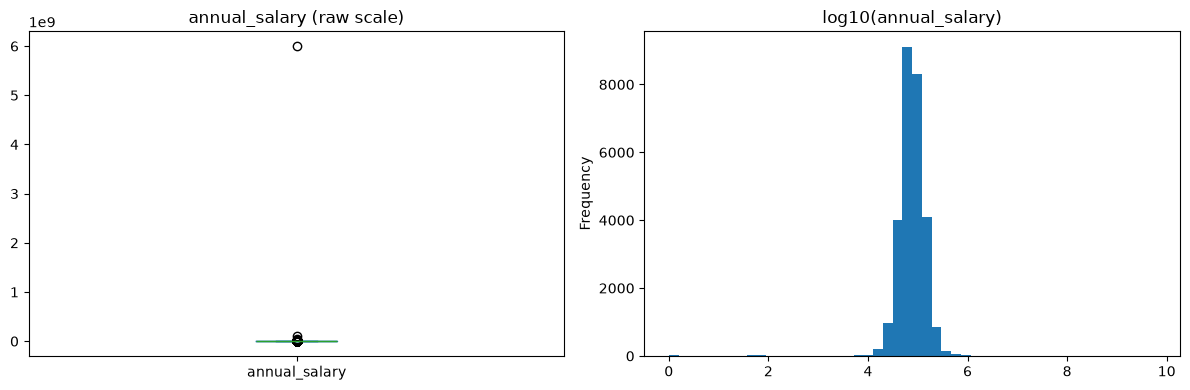

In [31]:
print(df['annual_salary'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['annual_salary'].plot(kind='box', ax=axes[0], title='annual_salary (raw scale)')
np.log10(df['annual_salary'].clip(lower=1)).plot(kind='hist', bins=50, ax=axes[1], title='log10(annual_salary)')
plt.tight_layout()
plt.show()

**Diagnosis:** `annual_salary` is heavily right-skewed, as expected for income data. A standard IQR
rule would flag many legitimate high tech/executive salaries as "outliers" just because of that skew,
not because they're wrong. What's actually worth scrutinizing are extreme values that aren't plausible
as a real annual salary, like `$1`, `$50`, or `$400,000,000`, these look more like data-entry errors (a
joke answer, an hourly rate typed in by mistake, an extra zero or two) than genuine pay.

**Decision:** Use fixed, domain-based bounds instead of a statistical rule that doesn't fit this
skewed distribution: flag rows with `annual_salary` under `10,000` or over `2,000,000` as implausible.
These are flagged in a new column first, not dropped right away, so the impact is visible before
removing anything.

In [32]:
LOWER_BOUND = 10_000
UPPER_BOUND = 2_000_000

df['salary_outlier_flag'] = ~df['annual_salary'].between(LOWER_BOUND, UPPER_BOUND)

n_outliers = df['salary_outlier_flag'].sum()
print(f"Flagged as outliers: {n_outliers} ({n_outliers/len(df)*100:.2f}% of rows)")
df.loc[df['salary_outlier_flag'], ['job_title', 'industry', 'country', 'annual_salary']].sort_values('annual_salary').head(10)

Flagged as outliers: 208 (0.74% of rows)


,job_title,industry,country,annual_salary
8739,Other,Other,United States,0
13537,Teacher (K-12),Education,United States,0
12615,Other,Legal,United States,0
10362,Director,Nonprofit,United States,0
20470,Other,Marketing,United States,0
20208,Other,Information Technology,United States,0
15238,Other,Information Technology,United States,0
15334,Other,Education,United States,0
23983,Other,Business/Consulting,United States,0
23028,Director,Nonprofit,United States,0


**Trade-off, made explicit:** this rule will remove a small number of genuine outliers along with
the errors — e.g. a real early-career stipend just under \$10k, or a real C-suite/celebrity-tier
compensation just over \$2M. It will also *miss* subtler errors (a typo that happens to land inside the
plausible range). Flagging instead of blind-dropping means that trade-off is visible and reversible: the
flagged rows are removed from the analysis-ready table below, but nothing is lost from the underlying
data — `salary_outlier_flag` records exactly which rows were excluded and why, so a future analysis can
choose a different threshold without re-deriving this from scratch.

In [33]:
df_analysis_ready = df[~df['salary_outlier_flag']].drop(columns=['salary_outlier_flag']).copy()

print(f"Rows kept for analysis-ready table: {len(df_analysis_ready)} / {len(df)}")

Rows kept for analysis-ready table: 27841 / 28049


# 4. Data Export

In [34]:
print("Final shape:", df_analysis_ready.shape)
df_analysis_ready.info()

Final shape: (27841, 9)
<class 'pandas.DataFrame'>
Index: 27841 entries, 0 to 28224
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   age_range                 27841 non-null  category
 1   industry                  27841 non-null  str     
 2   job_title                 27841 non-null  str     
 3   annual_salary             27841 non-null  int64   
 4   currency                  27841 non-null  str     
 5   country                   27841 non-null  str     
 6   current_years_experience  27841 non-null  category
 7   education                 27841 non-null  str     
 8   gender                    27841 non-null  str     
dtypes: category(2), int64(1), str(6)
memory usage: 1.8 MB


In [35]:
# Lock in dtypes for the categorical columns cleaned above (age_range and
# current_years_experience are already ordered categories from Section 4)
category_cols = ['industry', 'job_title', 'currency', 'country', 'education', 'gender']
for c in category_cols:
    df_analysis_ready[c] = df_analysis_ready[c].astype('category')

df_analysis_ready.dtypes

age_range                   category
industry                    category
job_title                   category
annual_salary                  int64
currency                    category
country                     category
current_years_experience    category
education                   category
gender                      category
dtype: object

In [36]:
print("Remaining nulls per column (should all be 0):")
df_analysis_ready.isnull().sum()

Remaining nulls per column (should all be 0):


age_range                   0
industry                    0
job_title                   0
annual_salary               0
currency                    0
country                     0
current_years_experience    0
education                   0
gender                      0
dtype: int64

**Final check:** every column should show 0 remaining nulls at this point — any that don't were
missed by an explicit decision above and need to be traced back to the relevant section rather than
patched here. `annual_salary` has no missingness by construction (0 nulls from the start; see Section 4)
and no further imputation was applied to it — only the outlier rows were removed in Section 5.

In [37]:
df_analysis_ready.to_csv('../Dataset/salary_survey_cleaned.csv', index=False)
print("Saved:", df_analysis_ready.shape)

Saved: (27841, 9)
